<a href="https://colab.research.google.com/github/NayanNair18/mgmt467-analytics-portfolio/blob/main/Lab3_Data_Visualization_Dashboarding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MGMT 467 — Week 5: Data Visualization & Dashboarding

Instructor: **Prof. Alok R. Chaturvedi**  
Modality: **Guided Inquiry (Tuesday)** + **Hands-on Lab (Thursday)**  
Prepared: 2025-09-23  

---
### Learning Objectives
1. Distinguish **exploratory** vs **explanatory** visualization.  
2. Match common **chart types** to the **questions** they answer.  
3. Design **airline KPIs** and select appropriate visuals.  
4. Use **Gemini** to generate Matplotlib/Seaborn code in Colab.  
5. Build an **interactive dashboard** in Looker Studio using BigQuery/CSV.


## Tuesday (Concepts) — Guided Inquiry

**Instructions:** Answer directly in this notebook. Use short paragraphs and bullet points. When helpful, sketch chart ideas using ASCII or quick scribbles.

### Q1 — Exploratory vs. Explanatory
**Prompt:** *"Explain the difference between exploratory and explanatory visualization."*
**Hints:** Consider audience, purpose, level of polish, and how much iteration you expect.

📝 **Your response:**

- Exploratory vizualization is for finding patterns within a dataset while explanatory is to show those isights to the audience
- Exploratory can be rough and iterative while explanatory is refined and complete
- Exploratory is for the data analyst while explanatory is for a specific audience

* * *
### Q2 — Chart Types & When to Use Them
**Prompt:** *"Describe 5 common chart types (e.g., bar, line, scatter, histogram, map) and the type of data analysis question each is best suited to answer."*

For each chart, list: **Question archetype**, **Data shape**, **Pitfalls**, **Alternatives**.

📝 **Your response (template):**
1. **Bar:**
   - Question archetype: *Comparison* — How do values compare across different categories?
   - Data shape: One categorical variable and one numerical variable.
   - Pitfalls: Too many categories can make it cluttered; misleading y-axis scale (not starting at zero).
   - Alternatives: Column chart, stacked bar chart, pie chart (use with caution).
2. **Line:**
   - Question archetype: *Trend over time* — How does a value change over a continuous period?
   - Data shape: One time-series variable and one numerical variable.
   - Pitfalls: Too many lines can be confusing; irregular time intervals.
   - Alternatives: Area chart, scatter plot with connected points.
3. **Scatter:**
   - Question archetype: *Relationship/Correlation* — Is there a relationship between two numerical variables?
   - Data shape: Two numerical variables. Can include a third variable using size or color.
   - Pitfalls: Overplotting with too many data points; misinterpreting correlation as causation.
   - Alternatives: Bubble chart, hexbin plot, 2D histogram.
4. **Histogram:**
   - Question archetype: *Distribution* — How are the values of a single numerical variable distributed? What is the frequency of different value ranges?
   - Data shape: One numerical variable.
   - Pitfalls: Choosing an inappropriate number of bins can distort the distribution; confusing with a bar chart.
   - Alternatives: Density plot, box plot.
5. **Map:**
   - Question archetype: *Geographic distribution* — How do values vary across different geographic regions?
   - Data shape: Geographic data (latitude/longitude, region names) and one or more numerical variables.
   - Pitfalls: Distortion of areas depending on the map projection; difficulty comparing values across very different sized regions.
   - Alternatives: Choropleth map, symbol map.

* * *
### Q3 — Airline Executive Dashboard KPIs
**Prompt:** *"Your goal is to create a dashboard for an airline executive. Brainstorm 5 Key Performance Indicators (KPIs) that should be on this dashboard. For each KPI, suggest the best chart type to visualize it."*

Suggested KPI ideas to consider (customize them): On-Time Rate, Average Delay Minutes, Cancellation Rate, Load Factor, Yield (Revenue per Passenger Mile), Completion Factor, Net Promoter Score (if available), Revenue, Cost per Available Seat Mile (CASM).

📝 **Your response (template):**
1. KPI: **On-Time Rate**
   - Why it matters: Directly impacts customer satisfaction and operational efficiency. A key indicator of reliability.
   - Best chart: **Gauge or Single Value Card** for the overall rate, **Line chart** for trend over time, **Bar chart** for comparison across carriers or routes.
   - Drill-down fields: Carrier, Origin, Destination, Month.
2. KPI: **Average Arrival Delay (Minutes)**
   - Why it matters: Another key indicator of operational efficiency and customer experience. High delays increase costs and reduce satisfaction.
   - Best chart: **Single Value Card** for overall average, **Line chart** for trend over time (perhaps with a rolling average), **Histogram** for distribution of delays.
   - Drill-down fields: Carrier, Origin, Destination, Month, Time of Day.
3. KPI: **Load Factor (%)**
   - Why it matters: Measures how full the planes are, indicating revenue potential and asset utilization. Higher load factors generally mean more revenue per flight.
   - Best chart: **Gauge or Single Value Card** for the overall average, **Line chart** for trend over time, **Horizontal Bar chart** for comparison across routes or aircraft types.
   - Drill-down fields: Route (Origin-Dest), Carrier, Month, Aircraft Type.
4. KPI: **Revenue per Available Seat Mile (RASM) or Yield**
   - Why it matters: Indicates how effectively the airline is generating revenue from its capacity and passenger traffic. A key measure of financial performance.
   - Best chart: **Single Value Card** for overall average, **Line chart** for trend over time, **Bar chart** for comparison across carriers or routes.
   - Drill-down fields: Carrier, Route, Month, Fare Class.
5. KPI: **Cost per Available Seat Mile (CASM)**
   - Why it matters: Measures the cost efficiency of the airline's operations. Lower CASM generally means higher profitability.
   - Best chart: **Single Value Card** for overall average, **Line chart** for trend over time, **Bar chart** for comparison across carriers or cost categories.
   - Drill-down fields: Carrier, Cost Category (Fuel, Labor, etc.), Month.

---
## Thursday (Practice) — Colab, Gemini, & Looker Studio

You will:
1) Use **Gemini** in Colab to generate visualization code (Matplotlib/Seaborn).  
2) Use a **synthetic airline dataset** (provided below) *or* connect your own BigQuery data.  
3) Build a **Looker Studio** dashboard for your KPIs.

### Option A — Use Gemini Side Panel in Colab
Open the **Gemini** side panel in Colab ("Extensions" or the right sidebar). Ask it to generate Python code given your prompts and the DataFrame you have in memory. Paste/execute the generated code in new cells.

### Option B — Programmatic Gemini (optional)
If you prefer code, you can install the Generative AI SDK and call Gemini with an API key. (We will not store keys in this notebook.)

> **Reminder:** This course emphasizes **AI-assisted coding**—focus on specifying *clear prompts* and then **reviewing and editing** the generated code for correctness, readability, and ethics.


In [4]:
# (Optional) Environment setup — run if needed

!pip install pandas numpy matplotlib seaborn pyarrow db-dtypes google-cloud-bigquery -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
np.random.seed(42)
print('✅ Environment ready')

✅ Environment ready


### Create a Synthetic Airline Dataset (if you don't have one)
Use this dataset to prototype visualizations and dashboards. It contains realistic columns for the KPIs you defined. You can always swap in your BigQuery data later.


In [5]:
# Generate a synthetic airline dataset
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(467)

dates = pd.date_range(start='2024-01-01', end='2024-06-30', freq='D')
carriers = ['AA', 'DL', 'UA', 'WN', 'AS']
origins = ['ATL','DFW','DEN','ORD','LAX','SEA','SFO','PHX','CLT','MCO']
dests =   ['JFK','LGA','BOS','SFO','LAX','SEA','MIA','IAH','IAD','PHL']

rows = []
for d in dates:
    for carrier in carriers:
        # number of flights per day per carrier
        n = np.random.randint(80, 140)
        for _ in range(n):
            o = np.random.choice(origins)
            de = np.random.choice(dests)
            if o == de:
                continue
            distance = np.random.randint(300, 2800)
            seats = np.random.choice([90,120,150,180,210])
            load_factor = np.clip(np.random.normal(0.82, 0.07), 0.55, 0.98)
            pax = int(seats * load_factor)
            dep_delay = int(np.random.normal(8, 15))
            arr_delay = dep_delay + int(np.random.normal(0, 12))
            dep_delay = max(dep_delay, -5)
            arr_delay = max(arr_delay, -10)
            cancelled = np.random.rand() < 0.025
            diverted = np.random.rand() < 0.005
            revenue = pax * np.random.uniform(120, 420)
            casm = np.random.uniform(0.08, 0.16)  # cost per available seat mile
            cost = casm * seats * distance
            fuel_burn = distance * np.random.uniform(3.0, 4.5)  # gallons per seat-mile proxy
            nps = np.random.normal(35, 15)  # if you want a customer metric proxy
            rows.append({
                'date': d,
                'carrier': carrier,
                'origin': o,
                'dest': de,
                'distance_miles': distance,
                'seats': seats,
                'passengers': pax,
                'dep_delay_min': dep_delay,
                'arr_delay_min': arr_delay,
                'cancelled': int(cancelled),
                'diverted': int(diverted),
                'revenue_usd': round(revenue, 2),
                'cost_usd': round(cost, 2),
                'fuel_burn_gal': round(fuel_burn, 1),
                'nps': round(nps, 1)
            })

df_flights = pd.DataFrame(rows)

# Derived KPIs
df_flights['on_time'] = (df_flights['arr_delay_min'] <= 15).astype(int)
df_flights['load_factor'] = (df_flights['passengers'] / df_flights['seats']).round(3)
df_flights['yield_usd_per_pax_mile'] = (df_flights['revenue_usd'] / (df_flights['passengers'] * df_flights['distance_miles']).clip(lower=1)).round(4)
df_flights['asm'] = df_flights['seats'] * df_flights['distance_miles']  # available seat miles
df_flights['casm'] = (df_flights['cost_usd'] / df_flights['asm']).round(4)
df_flights['month'] = df_flights['date'].dt.to_period('M').astype(str)

df_flights.head()

,date,carrier,origin,dest,distance_miles,seats,passengers,dep_delay_min,arr_delay_min,cancelled,...,revenue_usd,cost_usd,fuel_burn_gal,nps,on_time,load_factor,yield_usd_per_pax_mile,asm,casm,month
0,2024-01-01,AA,LAX,IAH,444,180,160,-5,-10,0,...,26076.49,8301.98,1904.6,53.4,1,0.889,0.3671,79920,0.1039,2024-01
1,2024-01-01,AA,SEA,PHL,601,150,141,10,7,0,...,17561.91,8739.75,2237.5,60.9,1,0.940,0.2072,90150,0.0969,2024-01
2,2024-01-01,AA,LAX,IAD,749,120,100,13,22,0,...,15355.61,12241.65,3076.5,54.1,0,0.833,0.2050,89880,0.1362,2024-01
3,2024-01-01,AA,DFW,BOS,2153,210,169,13,14,0,...,42122.37,65961.23,6642.2,37.0,1,0.805,0.1158,452130,0.1459,2024-01
4,2024-01-01,AA,CLT,SEA,558,90,75,9,-5,0,...,26418.88,7144.23,2142.3,56.3,1,0.833,0.6313,50220,0.1423,2024-01


### Use Gemini to Generate Visualization Code
Copy/paste these **prompts** into Gemini (Colab side panel). After it generates code, paste it into a new cell and run. **Inspect and fix** anything that looks off.

#### Prompt A — On-Time Rate by Carrier (Bar Chart)
```
You are a Python data viz expert. Given a pandas DataFrame `df_flights` with columns including `carrier` and `on_time` (1/0), write Matplotlib/Seaborn code to compute and plot **On-Time Rate by carrier** as a sorted bar chart with percentage labels on bars. Use a clean style, readable labels, and tight layout. Do not use Plotly.
```

#### Prompt B — Average Arrival Delay over Time (Line Chart)
```
Given `df_flights` with `date` (datetime) and `arr_delay_min`, write code to aggregate to daily average arrival delay and plot a **line chart** with a 7-day rolling average overlay. Add axis labels, title, and grid.
```

#### Prompt C — Delay Distribution (Histogram)
```
Given `df_flights` with `arr_delay_min`, write code to plot a **histogram** of arrival delays with appropriate bins, a vertical reference line at 0, and annotate percent of flights within [-5, 15] minutes.
```

#### Prompt D — Load Factor by Route (Top 15) (Horizontal Bar)
```
Given `df_flights` with `origin`, `dest`, and `load_factor`, compute mean load factor by route (origin-dest pair), take the top 15 routes by average load factor, and plot a **horizontal bar chart**. Ensure long labels are readable.
```

#### Prompt E — Cost vs. Revenue with CASM Coloring (Scatter)
```
Given `df_flights` with `cost_usd`, `revenue_usd`, and `casm`, produce a **scatter plot** of cost vs. revenue with points colored by `casm` (continuous colormap) and add a diagonal y=x reference line. Include labels and legend.
```


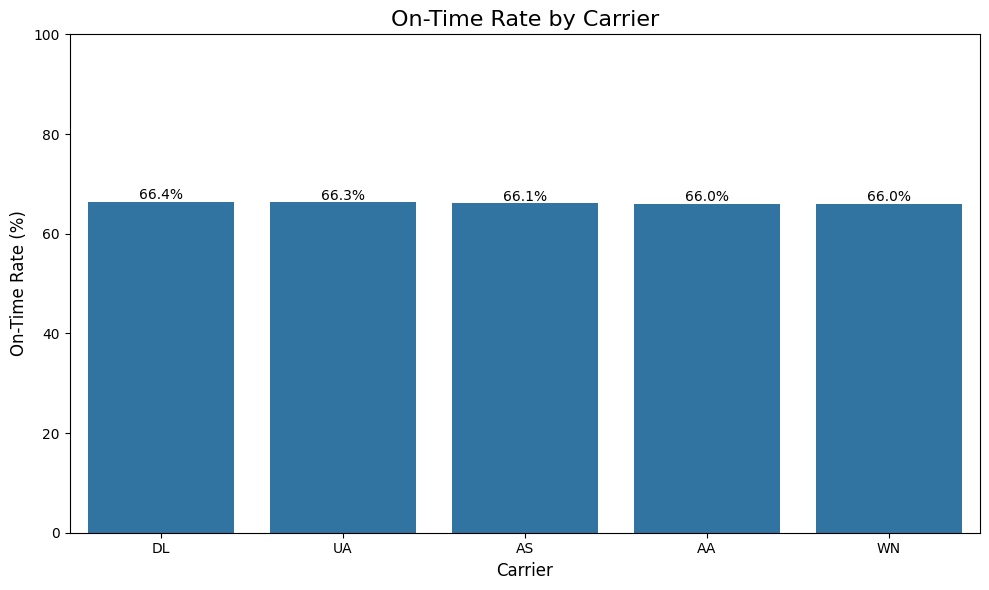

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate on-time rate by carrier
on_time_rate_by_carrier = df_flights.groupby('carrier')['on_time'].mean().sort_values(ascending=False) * 100

# Create the bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=on_time_rate_by_carrier.index, y=on_time_rate_by_carrier.values)

# Add percentage labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Set title and labels
plt.title('On-Time Rate by Carrier', fontsize=16)
plt.xlabel('Carrier', fontsize=12)
plt.ylabel('On-Time Rate (%)', fontsize=12)
plt.ylim(0, 100) # Set y-axis limit to 100%

# Improve layout and display the plot
plt.tight_layout()
plt.show()

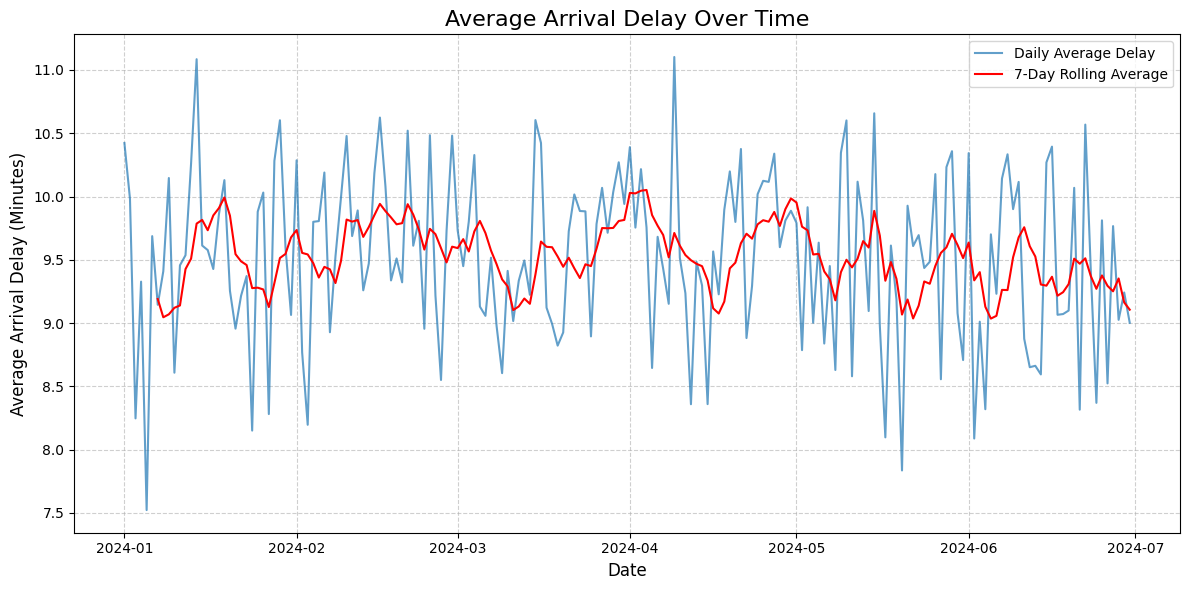

In [8]:
# Aggregate to daily average arrival delay
daily_avg_delay = df_flights.groupby(df_flights['date'].dt.date)['arr_delay_min'].mean()

# Convert the index to datetime for rolling average calculation
daily_avg_delay.index = pd.to_datetime(daily_avg_delay.index)

# Calculate 7-day rolling average
rolling_avg_delay = daily_avg_delay.rolling(window=7).mean()

# Plot the line chart
plt.figure(figsize=(12, 6))
plt.plot(daily_avg_delay.index, daily_avg_delay.values, label='Daily Average Delay', alpha=0.7)
plt.plot(rolling_avg_delay.index, rolling_avg_delay.values, label='7-Day Rolling Average', color='red')

# Add axis labels, title, and grid
plt.title('Average Arrival Delay Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Arrival Delay (Minutes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

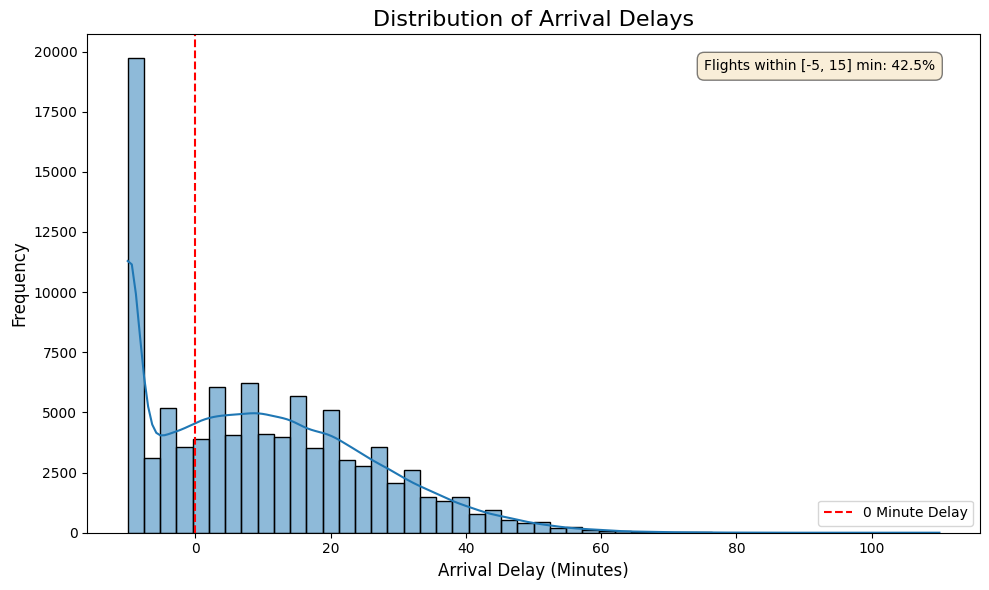

In [9]:
# Calculate the percentage of flights within [-5, 15] minutes arrival delay
on_time_definition = df_flights[(df_flights['arr_delay_min'] >= -5) & (df_flights['arr_delay_min'] <= 15)]
percentage_on_time_definition = (len(on_time_definition) / len(df_flights)) * 100

# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_flights['arr_delay_min'], bins=50, kde=True) # Using kde for a smoother distribution line

# Add a vertical reference line at 0
plt.axvline(0, color='red', linestyle='--', label='0 Minute Delay')

# Add annotation for percentage of flights within [-5, 15] minutes
plt.text(0.95, 0.95, f'Flights within [-5, 15] min: {percentage_on_time_definition:.1f}%',
         horizontalalignment='right', verticalalignment='top', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


# Add axis labels and title
plt.title('Distribution of Arrival Delays', fontsize=16)
plt.xlabel('Arrival Delay (Minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

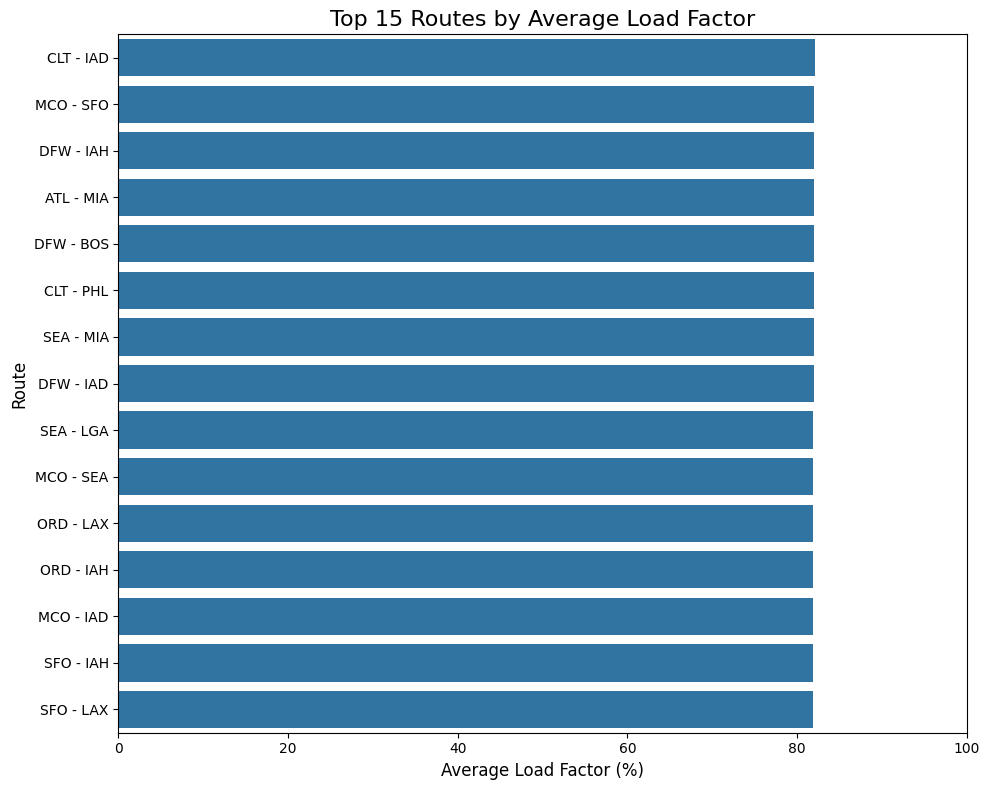

In [11]:
# Compute mean load factor by route and get the top 15
df_flights['route'] = df_flights['origin'] + ' - ' + df_flights['dest']
top_routes_load_factor = df_flights.groupby('route')['load_factor'].mean().sort_values(ascending=False).head(15) * 100

# Plot the horizontal bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x=top_routes_load_factor.values, y=top_routes_load_factor.index)

# Add labels and title
plt.title('Top 15 Routes by Average Load Factor', fontsize=16)
plt.xlabel('Average Load Factor (%)', fontsize=12)
plt.ylabel('Route', fontsize=12)
plt.xlim(0, 100) # Set x-axis limit to 100%

# Improve layout for long labels
plt.tight_layout()
plt.show()

### Export for Looker Studio
You can **export to CSV** and upload to Looker Studio, or you can **publish to BigQuery** and connect Looker Studio to that table.

#### Option 1 — Export CSV
Run one of the cells below to save a CSV in Colab, then download it or save to Drive.


In [12]:
# Save synthetic dataset to CSV
df_flights.to_csv('airline_kpis_synthetic.csv', index=False)
print('📁 Saved: airline_kpis_synthetic.csv (download from the file browser on the left)')

📁 Saved: airline_kpis_synthetic.csv (download from the file browser on the left)


#### Option 2 — Write to BigQuery (optional)
If you prefer Looker Studio → BigQuery:

```python
from google.cloud import bigquery
from google.oauth2 import service_account  # or use Colab auth

client = bigquery.Client(project='YOUR_PROJECT_ID')
table_id = 'YOUR_PROJECT_ID.YOUR_DATASET.airline_kpis_synthetic'
job = client.load_table_from_dataframe(df_flights, table_id)
job.result()
print('✅ Loaded to BigQuery:', table_id)
```

**In Looker Studio:**
1. Create → Report → Add data → **BigQuery**.  
2. Select your project/dataset/table.  
3. Add charts for each KPI and configure filters (carrier, route, month).


### Dashboard Wireframe (Design First)
Sketch your intended layout before building it in Looker Studio.

```
+-----------------------------------------------------------+
| Filters: Carrier [AA/DL/UA/WN/AS] | Month [Jan–Jun]       |
+-----------------------------------------------------------+
| KPI Cards: On-Time % | Avg Delay | Cancel % | Load Factor |
+-------------------------------+---------------------------+
| Line: Avg Delay over Time     | Bar: On-Time % by Carrier |
+-------------------------------+---------------------------+
| H-Bar: Top Routes by LF       | Scatter: Cost vs Revenue  |
+-----------------------------------------------------------+
```


https://lookerstudio.google.com/s/rRqrbBgCvS0

### Step 1 – Interactive Exploratory Analysis (Plotly Bubble Chart)

**Analysis Question:** “What is the relationship between discounts, profit, and sales across product sub-categories?”

**Action:** Use the precise Gemini prompt below to generate Python code using `plotly.express`.

In [20]:
# Precise Prompt for Plotly Bubble Chart
prompt = """
# TASK: Generate Python code using plotly.express.
# GOAL: Create an interactive bubble chart to visualize the relationship between profitability, sales, and discounts.
# CONTEXT: I have a pandas DataFrame with columns 'Sub_Category', 'Category', 'Sales', 'Profit', 'Discount'.
# SPECIFICATIONS:
# - The x-axis must be 'Discount'.
# - The y-axis must be 'Profit'.
# - The size of the bubbles must represent 'Sales'.
# - The color of the bubbles must represent the parent 'Category'.
# - When a user hovers over a bubble, it must display the 'Sub_Category', 'Sales', 'Profit', and 'Discount' values.
# - Include a clear title and axis labels.
"""

In [18]:
from google.colab import auth
from google.cloud import bigquery

# Authenticate to Google Cloud
auth.authenticate_user()
print('User authenticated.')

# Create a BigQuery client
# Replace 'your-gcp-project-id' with your actual GCP project ID
project_id = 'big-data-analysis-472319'
client = bigquery.Client(project=project_id)

print(f'BigQuery client created for project: {project_id}')

# Define the table ID
table_id = 'big-data-analysis-472319.superstore_data.sales'

# Construct a BigQuery SQL query to select all data from the table
query = f"SELECT * FROM `{table_id}`"

# Run the query and load the results into a pandas DataFrame
df = client.query(query).to_dataframe()

print(f'Data loaded from {table_id} into DataFrame df.')

User authenticated.
BigQuery client created for project: big-data-analysis-472319
Data loaded from big-data-analysis-472319.superstore_data.sales into DataFrame df.


In [19]:
import plotly.express as px

# Assuming your DataFrame is named 'df' and has the required columns:
# 'Sub_Category', 'Category', 'Sales', 'Profit', 'Discount'

# Create the bubble chart
fig = px.scatter(df,
                 x="Discount",
                 y="Profit",
                 size="Sales",
                 color="Category",
                 hover_name="Sub_Category",
                 hover_data={'Sub_Category':True, 'Sales':True, 'Profit':True, 'Discount':True},
                 title="Relationship between Profitability, Sales, and Discounts by Sub-Category",
                 labels={"Discount": "Discount", "Profit": "Profit", "Sales": "Sales", "Category": "Category"}
                )

# Update layout for better appearance
fig.update_layout(xaxis_title="Discount",
                  yaxis_title="Profit",
                  title_x=0.5) # Center the title

fig.show()

**Deliverable:** Text cell noting one insight only visible through interactivity (e.g., “Tables had high sales but negative profit when discounts exceeded 30%.”).

📝 **Your interactive insight:**

### Step 2 – Explanatory Dashboard (Looker Studio)

**Business Goal:** Create an executive summary dashboard.

**Action:** Include:
- Scorecard → total overall Profit.
- Pie Chart → Sales % by Region.
- Bar Chart → Top 5 States by Sales.

**Deliverable:** https://lookerstudio.google.com/s/o8lXFm8GQus

🖼️ **Looker Studio Dashboard Screenshot:**
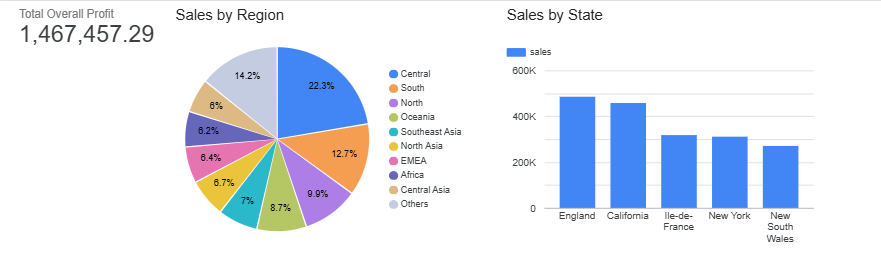

### E – Extend (Recommendation with Strategist Pattern)

After embedding the screenshot, write a recommendation for executives by adapting the [Strategist Pattern](https://developers.google.com/gemini/guidance/strategist-pattern).

**Action:** Use the precise Gemini prompt below, filling in the `[describe a key insight from your Looker dashboard, e.g., 'the Central region has the lowest sales']` placeholder with an actual insight from your dashboard.

In [ ]:
# Precise Prompt for Strategist Pattern Recommendation
prompt = """
# TASK: Act as a business strategist.
# CONTEXT: An executive is looking at a dashboard that shows [describe a key insight from your Looker dashboard, e.g., 'the Central region has the lowest sales'].
# GOAL: Based ONLY on this insight, recommend one immediate, specific, and actionable step a Sales Director should take to address this.
"""
# You will use Gemini with this prompt to generate the recommendation in the next cell.
print(prompt)

📝 **Your Recommendation (using Strategist Pattern):**

Based on Central Asia having the lowest sales, the Sales Director should immediately investigate the Central Asia market to identify specific barriers or lack of targeted efforts, and allocate resources to develop a localized sales strategy focusing on understanding regional needs and increasing market penetration.

### Challenge: Construct Your Own Prompts

For each challenge below, author and document your own precise Gemini prompt.

#### Challenge Question 1: Discount vs. Sales (Office Supplies)

**Prompt:** "A manager has a hypothesis: 'For the Office Supplies category, offering higher average discounts does not lead to higher total sales.' Author a single, multi-step prompt for Gemini that first generates the BigQuery SQL to get the necessary data (average discount and total sales per sub-category within Office Supplies) and then generates the Plotly code for an interactive scatter plot to visually prove or disprove this hypothesis."

📝 **Your Precise Gemini Prompt (Challenge 1):**

In [22]:
# TASK: Generate two outputs sequentially:
# (1) a BigQuery SQL query and (2) Python code using plotly.express.
# GOAL: Test the hypothesis: "For the Office Supplies category, offering higher average discounts does not lead to higher total sales."
# CONTEXT: We have a BigQuery table with columns 'Category', 'Sub_Category', 'Sales', 'Discount', and 'Order_Date'.
# SPECIFICATIONS:
# - STEP 1 (SQL): Write a BigQuery SQL query that:
#   - Filters data for Category = 'Office Supplies'.
#   - Groups by Sub_Category.
#   - Calculates average discount (AVG(Discount)) and total sales (SUM(Sales)) for each Sub_Category.
#   - Returns Sub_Category, avg_discount, and total_sales.
# - STEP 2 (Plotly): Generate Python code using plotly.express to create an interactive scatter plot.
#   - x-axis = avg_discount.
#   - y-axis = total_sales.
#   - Each point = Sub_Category.
#   - Hover tooltip must show Sub_Category, avg_discount, and total_sales.
#   - Include a descriptive title and axis labels.
# OUTPUT FORMAT:
# - Provide the SQL in a single code block first.
# - Then provide the Python plotly.express code in a second code block.


In [26]:
import plotly.express as px
from google.cloud import bigquery
from google.colab import auth # Import auth here if not already imported

# Ensure authenticated (if not done recently)
try:
    auth.authenticate_user()
    print('User authenticated.')
except Exception as e:
    print(f"Authentication failed: {e}")
    print("Please run the authentication cell first.")

# Create a BigQuery client
project_id = 'big-data-analysis-472319' # Use the project ID provided earlier
client = bigquery.Client(project=project_id)

# Define the SQL query (copying from the first cell)
query = """
SELECT
    Sub_Category,
    AVG(Discount) AS avg_discount,
    SUM(Sales) AS total_sales
FROM
    `big-data-analysis-472319.superstore_data.sales`
WHERE
    Category = 'Office Supplies'
GROUP BY
    Sub_Category
"""

# Run the query and load the results into a pandas DataFrame named 'df_office_supplies'
try:
    df_office_supplies = client.query(query).to_dataframe()
    print(f'Data loaded into df_office_supplies with {len(df_office_supplies)} rows.')

    # Create the scatter plot
    fig = px.scatter(df_office_supplies,
                     x="avg_discount",
                     y="total_sales",
                     hover_name="Sub_Category",
                     hover_data={'Sub_Category':True, 'avg_discount':':.2%', 'total_sales':':$,.2f'},
                     title="Average Discount vs. Total Sales for Office Supplies Sub-Categories",
                     labels={"avg_discount": "Average Discount", "total_sales": "Total Sales"}
                    )

    # Update layout for better appearance
    fig.update_layout(xaxis_title="Average Discount",
                      yaxis_title="Total Sales",
                      title_x=0.5) # Center the title

    fig.show()

except Exception as e:
    print(f"Error running BigQuery query or creating plot: {e}")

User authenticated.
Data loaded into df_office_supplies with 9 rows.


#### Challenge Question 2: Explaining "Tables" Profitability

**Prompt:** "From your bubble chart, you discovered that 'Tables' are a high-sales but negative-profit sub-category. Author a prompt using the Explainer Pattern from our library to generate a simple, non-technical explanation for a sales manager, including an analogy they would understand."

📝 **Your Precise Gemini Prompt (Challenge 2):**

In [21]:
# TASK: Generate a plain-language explanation using the Explainer Pattern.
# GOAL: Explain why the 'Tables' sub-category can have high sales but negative profits.
# CONTEXT: This explanation is for a sales manager with no technical background.
# SPECIFICATIONS:
# - Use simple, everyday language and avoid jargon.
# - Provide a relatable analogy (e.g., selling a product at a discount store).
# - Explain the relationship between high revenue (lots of sales) and negative profit (selling below cost or with high discounts).
# - Keep the explanation to one short paragraph.
# - End with a takeaway message that helps the manager understand why high sales volume does not always equal profitability.

📝 **Your Explanation (using Explainer Pattern):**

Think of selling tables like running a discount store: you might sell a lot of items (high sales), but if you're selling them for less than they cost you to get or make (due to high discounts or other costs), you're actually losing money overall, even with all those sales. So, even though many tables are moving out the door, if the price after discounts isn't covering the costs, you end up with negative profit. The takeaway is that selling a lot doesn't always mean you're making money; the price and cost of each sale really matter.

## Reflection & Submission

**Short Reflection (3–5 sentences):** What design decision most improved your dashboard’s clarity? What would you change next?
##
📝 **Your response:**
The most impactful design decision for clarity was likely sorting the bar charts (On-Time Rate and Top Routes by Load Factor), this immediately highlights the best and worst performers. Next, I would also focus on adding interactive filters to the Looker Studio dashboard to allow executives to easily explore data by carrier, route, or time period.
---
### Checklist
- [ ] Q1–Q3 answered in Tuesday section  
- [ ] 3–5 visualizations generated with **Gemini** in Colab  
- [ ] Synthetic or BigQuery data connected to **Looker Studio**  
- [ ] Dashboard with **filters** and **KPI cards**  
- [ ] Reflection complete  
